# Поиск ключевых точек

In [172]:
import torch
import torchvision
import torchvision.transforms as T
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Загружаем предобученную модель Keypoint R-CNN
model = torchvision.models.detection.keypointrcnn_resnet50_fpn(pretrained=True)
model.eval()  # переводим в режим инференса

# Если доступен GPU, используем его
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)

KeypointRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(640, 672, 704, 736, 768, 800), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.

Список ключевых точек (в порядке, который выдаёт модель COCO)

In [173]:
keypoints = ['nose', 'left_eye', 'right_eye',
             'left_ear', 'right_ear', 'left_shoulder',
             'right_shoulder', 'left_elbow', 'right_elbow',
             'left_wrist', 'right_wrist', 'left_hip',
             'right_hip', 'left_knee', 'right_knee',
             'left_ankle', 'right_ankle']

Загрузка изображения и применение трансформаций

In [174]:
img_pil = Image.open('data/dspr_cv_u1_diploma_spr1_3_1.png').convert("RGB")

# Сохраняем оригинал в RGB для дальнейшего отображения
img_rgb = np.array(img_pil)

# Трансформация: PIL -> Tensor
transform = T.Compose([T.ToTensor()])
img_tensor = transform(img_pil).unsqueeze(0).to(device)  # добавляем batch dimension

Прогон изображения через модель

In [175]:
with torch.no_grad():
    outputs = model(img_tensor)

output = outputs[0]
boxes = output['boxes'].cpu()
labels = output['labels'].cpu()
scores = output['scores'].cpu()
keypoints_all = output['keypoints'].cpu()
keypoints_scores = output['keypoints_scores'].cpu()

print(f"Обнаружено людей: {len(boxes)}")
print("Уверенность каждой детекции:", scores.numpy())

Обнаружено людей: 2
Уверенность каждой детекции: [0.99974066 0.16493176]


Функция отрисовки ключевых точек (немного доработанная для коррекции цвета)

In [176]:
def draw_keypoints_per_person(img, all_keypoints, all_scores, confs,
                              keypoint_threshold=2, conf_threshold=0.9):
    """
    Рисует ключевые точки, используя видимость (третий канал keypoints).
    keypoint_threshold: минимальное значение видимости (обычно 2 для видимых точек).
    """
    cmap = plt.get_cmap("rainbow")
    img_copy = img.copy()
    n_people = len(all_keypoints)
    if n_people == 0:
        return img_copy
    color_ids = np.linspace(0, 255, n_people, dtype=int).tolist()[::-1]

    for person_id in range(n_people):
        if confs[person_id] > conf_threshold:
            keypoints = all_keypoints[person_id]          # [17, 3]
            visibility = keypoints[:, 2]                  # [17] – значения 0,1,2

            color_rgb = np.array(cmap(color_ids[person_id])[:3]) * 255
            color_bgr = (int(color_rgb[2]), int(color_rgb[1]), int(color_rgb[0]))

            for kp_idx, vis in enumerate(visibility):
                if vis >= keypoint_threshold:             # например, >=2
                    x, y = keypoints[kp_idx, :2].int().tolist()
                    cv2.circle(img_copy, (x, y), 5, color_bgr, -1)
    return img_copy

Применяем функцию отрисовки ключевых точек.

Для этого преобразуем исходное RGB-изображение в BGR.

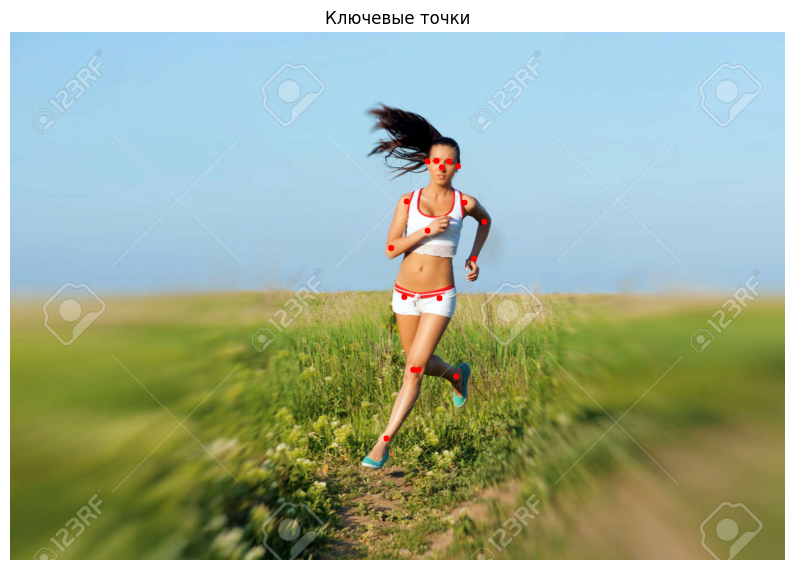

In [177]:
img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)

img_with_keypoints = draw_keypoints_per_person(
    img_bgr,
    keypoints_all,
    keypoints_scores,
    scores,
    keypoint_threshold=1,
    conf_threshold=0.9
)

# Отобразим результат (для просмотра в Jupyter преобразуем BGR обратно в RGB)
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(img_with_keypoints, cv2.COLOR_BGR2RGB))
plt.title("Ключевые точки")
plt.axis('off')
plt.show()

Функция для построения списка конечностей (limbs)

In [178]:
def get_limbs_from_keypoints(keypoints):
    limbs = [
        [keypoints.index("right_eye"), keypoints.index("nose")],
        [keypoints.index("right_eye"), keypoints.index("right_ear")],
        [keypoints.index("left_eye"), keypoints.index("nose")],
        [keypoints.index("left_eye"), keypoints.index("left_ear")],
        [keypoints.index("right_shoulder"), keypoints.index("right_elbow")],
        [keypoints.index("right_elbow"), keypoints.index("right_wrist")],
        [keypoints.index("left_shoulder"), keypoints.index("left_elbow")],
        [keypoints.index("left_elbow"), keypoints.index("left_wrist")],
        [keypoints.index("right_hip"), keypoints.index("right_knee")],
        [keypoints.index("right_knee"), keypoints.index("right_ankle")],
        [keypoints.index("left_hip"), keypoints.index("left_knee")],
        [keypoints.index("left_knee"), keypoints.index("left_ankle")],
        [keypoints.index("right_shoulder"), keypoints.index("left_shoulder")],
        [keypoints.index("right_hip"), keypoints.index("left_hip")],
        [keypoints.index("right_shoulder"), keypoints.index("right_hip")],
        [keypoints.index("left_shoulder"), keypoints.index("left_hip")],
    ]
    return limbs

limbs = get_limbs_from_keypoints(keypoints)
print("Количество конечностей:", len(limbs))

Количество конечностей: 16


Функция для отрисовки скелета (ключевые точки + соединения)

In [179]:
def draw_skeleton(img, all_keypoints, all_scores, confs, limbs,
                  keypoint_threshold=2, conf_threshold=0.9):
    """
    Рисует скелет (точки + соединения), используя видимость.
    """
    cmap = plt.get_cmap("rainbow")
    img_copy = img.copy()
    n_people = len(all_keypoints)
    if n_people == 0:
        return img_copy
    color_ids = np.linspace(0, 255, n_people, dtype=int).tolist()[::-1]

    for person_id in range(n_people):
        if confs[person_id] > conf_threshold:
            keypoints = all_keypoints[person_id]
            visibility = keypoints[:, 2]

            color_rgb = np.array(cmap(color_ids[person_id])[:3]) * 255
            color_bgr = (int(color_rgb[2]), int(color_rgb[1]), int(color_rgb[0]))

            # Рисуем точки
            for kp_idx, vis in enumerate(visibility):
                if vis >= keypoint_threshold:
                    x, y = keypoints[kp_idx, :2].int().tolist()
                    cv2.circle(img_copy, (x, y), 5, color_bgr, -1)

            # Рисуем конечности (соединения)
            for limb in limbs:
                idx1, idx2 = limb
                if visibility[idx1] >= keypoint_threshold and visibility[idx2] >= keypoint_threshold:
                    x1, y1 = keypoints[idx1, :2].int().tolist()
                    x2, y2 = keypoints[idx2, :2].int().tolist()
                    cv2.line(img_copy, (x1, y1), (x2, y2), color_bgr, 2)
    return img_copy

Отрисовываем скелет на изображении

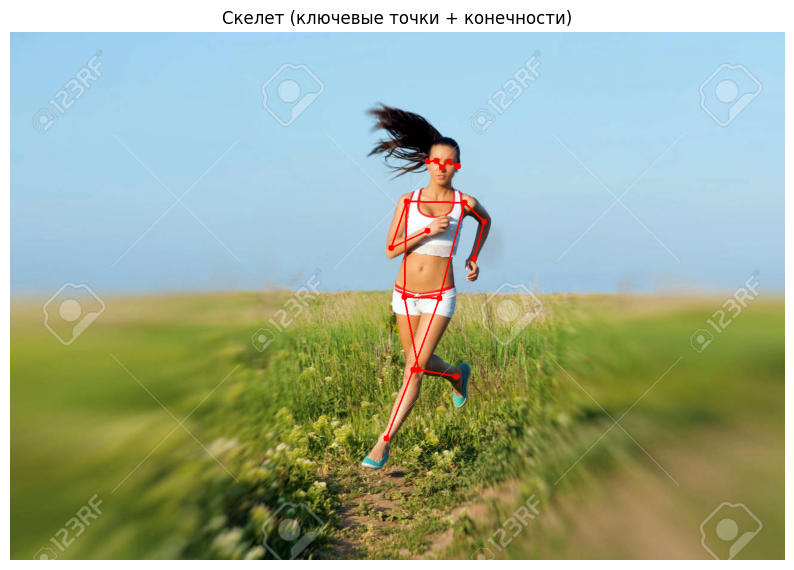

In [180]:
img_with_skeleton = draw_skeleton(
    img_bgr,
    keypoints_all,
    keypoints_scores,
    scores,
    limbs,
    keypoint_threshold=1,
    conf_threshold=0.9
)

# Отображаем результат
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(img_with_skeleton, cv2.COLOR_BGR2RGB))
plt.title("Скелет (ключевые точки + конечности)")
plt.axis('off')
plt.show()

# Оценка сходства поз по фотографии

Функция получения ключевых точек из изображения

In [181]:
def get_keypoints(image_pil, model, device, conf_threshold=0.9):
    transform = T.Compose([T.ToTensor()])
    img_tensor = transform(image_pil).unsqueeze(0).to(device)
    with torch.no_grad():
        outputs = model(img_tensor)
    output = outputs[0]
    scores = output['scores'].cpu()
    keypoints_all = output['keypoints'].cpu()
    keypoints_scores = output['keypoints_scores'].cpu()

    valid = scores > conf_threshold
    if not valid.any():
        return None, None, None
    best_idx = scores[valid].argmax().item()
    original_indices = torch.where(valid)[0]
    idx = original_indices[best_idx].item()
    # Возвращаем координаты (x,y) и достоверности
    return keypoints_all[idx, :, :2].numpy(), keypoints_scores[idx].numpy(), scores[idx].item()

Загружаем два изображения

In [182]:
# Модельное изображение
model_pil = Image.open('data/dspr_cv_u1_diploma_spr1_3_1.png').convert("RGB")

# Входное изображение 1 для сравнения
input_pil_1 = Image.open('data/test.jpg').convert("RGB")

# Входное изображение 2 для сравнения
input_pil_2 = Image.open('data/test_2.jpg').convert("RGB")

# Получаем ключевые точки
model_pts, model_scores, model_conf = get_keypoints(model_pil, model, device)
input_pts_1, input_scores_1, input_conf_1 = get_keypoints(input_pil_1, model, device)
input_pts_2, input_scores_2, input_conf_2 = get_keypoints(input_pil_2, model, device)

if model_pts is None or input_pts_1 is None:
    raise ValueError("Не удалось обнаружить человека на одном из изображений")

if model_pts is None or input_pts_2 is None:
    raise ValueError("Не удалось обнаружить человека на одном из изображений")

print(f"Модельная поза: уверенность {model_conf:.3f}")
print(f"Входная поза 1: уверенность {input_conf_1:.3f}")
print(f"Входная поза 2: уверенность {input_conf_2:.3f}")

Модельная поза: уверенность 1.000
Входная поза 1: уверенность 0.999
Входная поза 2: уверенность 1.000


Аффинное преобразование входной позы к модельной

In [183]:
pad = lambda x: np.hstack([x, np.ones((x.shape[0], 1))])
unpad = lambda x: x[:, :-1]

# Расширяем наборы
X_1 = pad(input_pts_1)   # (17,3)
X_2 = pad(input_pts_2)   # (17,3)
Y = pad(model_pts)   # (17,3)

# Решаем задачу наименьших квадратов: X @ A = Y
A_1, res_1, rank_1, s_1 = np.linalg.lstsq(X_1, Y, rcond=None)
A_1[np.abs(A_1) < 1e-10] = 0   # обнуляем слишком малые значения

A_2, res_2, rank_2, s_2 = np.linalg.lstsq(X_2, Y, rcond=None)
A_2[np.abs(A_2) < 1e-10] = 0   

# Преобразуем входные точки
input_transformed_1 = unpad(np.dot(pad(input_pts_1), A_1))   # (17,2)
input_transformed_2 = unpad(np.dot(pad(input_pts_2), A_2))  

In [184]:
def draw_two_skeletons_on_model(img_pil, model_pts, model_scores, input_transformed, input_scores, threshold=0.5):
    """
    Рисует модельный скелет (зелёным) и преобразованный входной скелет (красным)
    на изображении модели.
    """
    img_bgr = cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)
    limbs = [
        (0,1), (0,2), (1,3), (2,4),
        (5,7), (7,9), (6,8), (8,10),
        (11,13), (13,15), (12,14), (14,16),
        (5,6), (11,12), (5,11), (6,12)
    ]
    # Рисуем модельный скелет (зелёный)
    for (idx1, idx2) in limbs:
        if model_scores[idx1] > threshold and model_scores[idx2] > threshold:
            x1, y1 = int(model_pts[idx1,0]), int(model_pts[idx1,1])
            x2, y2 = int(model_pts[idx2,0]), int(model_pts[idx2,1])
            cv2.line(img_bgr, (x1,y1), (x2,y2), (0,255,0), 2)
    for i, pt in enumerate(model_pts):
        if model_scores[i] > threshold:
            x, y = int(pt[0]), int(pt[1])
            cv2.circle(img_bgr, (x,y), 4, (0,255,0), -1)

    # Рисуем преобразованный входной скелет (красный)
    for (idx1, idx2) in limbs:
        if input_scores[idx1] > threshold and input_scores[idx2] > threshold:
            x1, y1 = int(input_transformed[idx1,0]), int(input_transformed[idx1,1])
            x2, y2 = int(input_transformed[idx2,0]), int(input_transformed[idx2,1])
            cv2.line(img_bgr, (x1,y1), (x2,y2), (0,0,255), 2)
    for i, pt in enumerate(input_transformed):
        if input_scores[i] > threshold:
            x, y = int(pt[0]), int(pt[1])
            cv2.circle(img_bgr, (x,y), 4, (0,0,255), -1)

    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

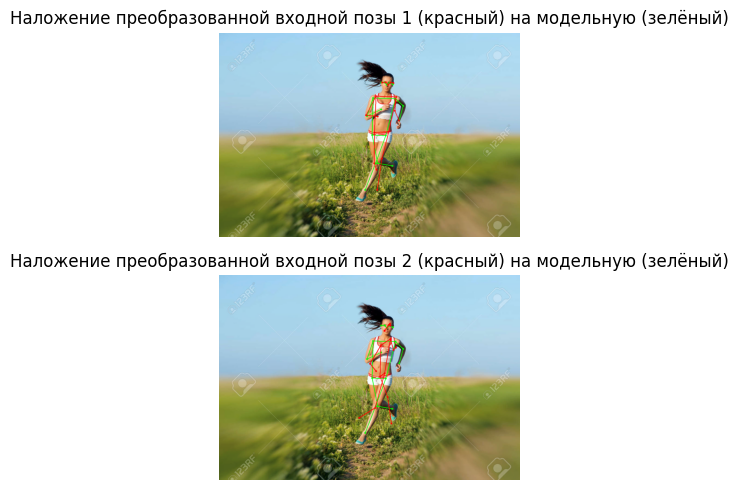

In [185]:
# Отображаем наложение
plt.figure(figsize=(12, 5))

# Первое изображение
plt.subplot(2, 1, 1)  # 1 строка, 2 колонки, первый график
plt.imshow(draw_two_skeletons_on_model(model_pil, model_pts, model_scores, input_transformed_1, input_scores_1, threshold=0.5))
plt.title("Наложение преобразованной входной позы 1 (красный) на модельную (зелёный)")
plt.axis('off')

# Второе изображение
plt.subplot(2, 1, 2)  # 1 строка, 2 колонки, второй график
plt.imshow(draw_two_skeletons_on_model(model_pil, model_pts, model_scores, input_transformed_2, input_scores_2, threshold=0.5))
plt.title("Наложение преобразованной входной позы 2 (красный) на модельную (зелёный)")
plt.axis('off')

# Автоматически подгоняем расстояния между подграфиками
plt.tight_layout()
plt.show()

Функции сравнения

In [186]:
def cosine_distance(pose1, pose2):
    """pose1 и pose2 - одномерные векторы (например, 34 элемента)"""
    v1 = pose1.flatten()
    v2 = pose2.flatten()
    cos_sim = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
    return cos_sim

def weighted_distance(pose1, pose2, conf1):
    """
    pose1, pose2 - одномерные векторы координат (x1,y1,x2,y2,...)
    conf1 - достоверности ключевых точек (17 значений)
    """
    sum_conf = np.sum(conf1)
    if sum_conf == 0:
        return float('inf')
    weighted_sum = 0.0
    for i in range(len(pose1)):
        keypoint_idx = i // 2   # индекс ключевой точки (0..16)
        weighted_sum += conf1[keypoint_idx] * abs(pose1[i] - pose2[i])
    return weighted_sum / sum_conf

In [187]:
# Подготовим одномерные векторы
model_vec = model_pts.flatten()                 # (34,)
input_transformed_vec_1 = input_transformed_1.flatten()   # (34,)
input_transformed_vec_2 = input_transformed_2.flatten()   # (34,)

# Вычисляем метрики
cos_dist_1 = cosine_distance(model_vec, input_transformed_vec_1)
w_dist_1 = weighted_distance(input_transformed_vec_1, model_vec, input_scores_1)

cos_dist_2 = cosine_distance(model_vec, input_transformed_vec_2)
w_dist_2 = weighted_distance(input_transformed_vec_2, model_vec, input_scores_2)

print(f"Косинусное сходство 1 изображения: {cos_dist_1:.4f}")
print(f"Взвешенное расстояние 1 изображения: {w_dist_1:.4f}")

print(f"Косинусное сходство 2 изображения: {cos_dist_2:.4f}")
print(f"Взвешенное расстояние 2 изображения: {w_dist_2:.4f}")

Косинусное сходство 1 изображения: 0.9994
Взвешенное расстояние 1 изображения: 22.3786
Косинусное сходство 2 изображения: 0.9985
Взвешенное расстояние 2 изображения: 44.3450


Визуализация

In [188]:
def draw_skeleton_on_image(img_pil, keypoints, scores, threshold=0.5):
    img_bgr = cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)
    cmap = plt.get_cmap("rainbow")
    # Используем тот же скелет, что и в предыдущем спринте (лимиты из limbs)
    limbs = [[1,2],[1,3],[2,4],[3,5],[6,8],[8,10],[7,9],[9,11],[12,14],[14,16],[13,15],[15,17],
             [6,7],[12,13],[6,12],[7,13]]
    # Индексы в COCO: 1..17, в коде списка ключевых точек индексы 0..16
    limbs = [[a-1, b-1] for a,b in limbs]
    # Рисуем только для одного человека
    color_bgr = (0,255,0)   # зелёный
    for (idx1, idx2) in limbs:
        if scores[idx1] > threshold and scores[idx2] > threshold:
            x1, y1 = int(keypoints[idx1,0]), int(keypoints[idx1,1])
            x2, y2 = int(keypoints[idx2,0]), int(keypoints[idx2,1])
            cv2.line(img_bgr, (x1,y1), (x2,y2), color_bgr, 2)
    for i, pt in enumerate(keypoints):
        if scores[i] > threshold:
            x,y = int(pt[0]), int(pt[1])
            cv2.circle(img_bgr, (x,y), 4, color_bgr, -1)
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

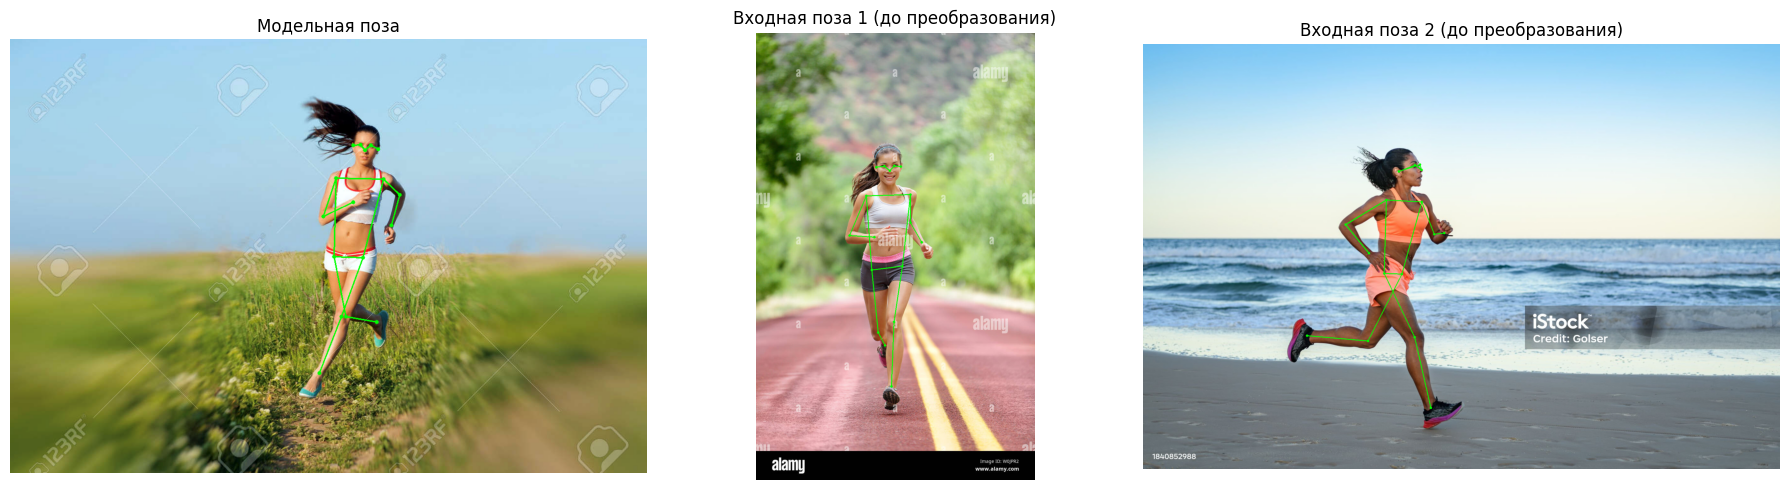

In [189]:
# Отобразим исходную модельную позу и преобразованную входную (наложим для наглядности)
plt.figure(figsize=(18,5))
plt.subplot(1,3,1)
plt.imshow(draw_skeleton_on_image(model_pil, model_pts, model_scores, threshold=0.5))
plt.title("Модельная поза")
plt.axis('off')

plt.subplot(1,3,2)
# Покажем входное изображение 1 с его скелетом
plt.imshow(draw_skeleton_on_image(input_pil_1, input_pts_1, input_scores_1, threshold=0.5))
plt.title("Входная поза 1 (до преобразования)")
plt.axis('off')

plt.subplot(1,3,3)
# Покажем входное изображение 2 с его скелетом
plt.imshow(draw_skeleton_on_image(input_pil_2, input_pts_2, input_scores_2, threshold=0.5))
plt.title("Входная поза 2 (до преобразования)")
plt.axis('off')

plt.tight_layout()
plt.show()

# Результаты сравнения поз

Для первого изображения

| Метрика                   | Значение   | Интерпретация                                      |
|---------------------------|------------|----------------------------------------------------|
| **Косинусное сходство**   | `0.9994`   | Позы имеют почти идентичную форму и ориентацию  |
| **Взвешенное расстояние** | `22.3786`    | Умеренное расхождение по точкам (в пикселях)     |

---

Для второго изображения

| Метрика                   | Значение   | Интерпретация                                      |
|---------------------------|------------|----------------------------------------------------|
| **Косинусное сходство**   | `0.9985`   | Позы имеют почти идентичную форму и ориентацию  |
| **Взвешенное расстояние** | `44.3450`    | Расхождение по точкам в пикселях в 2 раза больше, но здесь направление движения отличается |


# Вывод:
Пользователь **хорошо повторил позу**:
- Форма и направления суставов совпадают почти идеально.
- Есть незначительные отклонения в позиционировании тела.
